## Plot trends in river discharge from CESM LENS2
#### Author: M. A. Freilich, S. Gangrade
#### Associated manuscript: Gangrade et al., 2026 (GRL) 

In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import bootstrap

In [11]:
# Load data
data = pd.read_csv('LENS2_discharge_US_west.csv')
time = pd.to_datetime(data.time)
years = time.values.astype('datetime64[Y]').astype(int) + 1970
months = time.values.astype('datetime64[M]').astype(int) % 12 + 1
tot = data.total
df = pd.DataFrame({'time': time, 'total': tot, 'year': years, 'month': months})

In [12]:
df

,time,total,year,month
0,1850-02-01,16888.664601,1850,2
1,1850-03-01,10422.023097,1850,3
2,1850-04-01,17137.948861,1850,4
3,1850-05-01,9755.316113,1850,5
4,1850-06-01,7949.762407,1850,6
...,...,...,...,...
271075,2100-09-01,1440.503795,2100,9
271076,2100-10-01,1009.684938,2100,10
271077,2100-11-01,1419.444373,2100,11
271078,2100-12-01,3236.882111,2100,12


In [13]:
# Identify useful threshold for discharge values (above which we consider it 'high' outflow/discharge)
1-sum(tot > 20e3)/len(tot) # obtain the percentile of the threshold 20e3
# prctile_discharge_96 = np.percentile(tot, 96)
# prctile_discharge_96 # approximately 20e3

0.9639921794304265

In [14]:
# Define functions to identify fraction of ensemble member with high outflow/discharge (above threshold)
def high_outflow(data,thres = 20e3):
    frac = np.sum(data.total > thres)/data.shape[0]
    return frac

def high_outflow1(data,thres = 20e3):
    frac = np.sum(data > thres)/data.shape[0]
    return frac

In [15]:
# Subset for April discharge values
data = df[(df.month == 4) & (df.year == 2050)]
data

,time,total,year,month
178622,2050-04-01,21655.337866,2050,4
179654,2050-04-01,4992.583402,2050,4
180686,2050-04-01,22180.680931,2050,4
181718,2050-04-01,12121.861000,2050,4
182750,2050-04-01,11407.427897,2050,4
...,...,...,...,...
266342,2050-04-01,22947.418197,2050,4
267374,2050-04-01,19804.830608,2050,4
268406,2050-04-01,9316.053756,2050,4
269438,2050-04-01,11760.618601,2050,4


In [16]:
# Filter data for April values, keep data separate by year, compute fraction of ensemble members with outflow above threshold, multiply fraction by 100
ext = df[df.month == 4].groupby('year').apply(high_outflow)*100 

# Apply bootstrap function to obtain 75th percentile confidence intervals of April discharge data, for all ensemnble members, and for each year (i)
y = np.unique(df.year)
cilow = np.empty(0)
cihigh = np.empty(0)
for i in y[:-1]:
    data = df[(df.month == 4) & (df.year == i)].total.values # take the total discharge for the month of April in each year
    res = bootstrap((data,), high_outflow1, confidence_level=0.75)
    cilow = np.append(cilow,res.confidence_interval.low)
    cihigh = np.append(cihigh,res.confidence_interval.high)

/var/folders/k_/1rf2sqks5hz51srpqg10rhh00000gn/T/ipykernel_51199/4189736818.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ext = df[df.month == 4].groupby('year').apply(high_outflow)*100


In [17]:
# Apply a 30-year rolling mean to df_ext (data frame holding proportion of ensemble members with high April discharge)
df_ext = pd.DataFrame({'ext': ext, 'cilow': cilow*100, 'cihigh': cihigh*100})
df_ext30 = df_ext.rolling(30, center=True).apply(lambda x : np.mean(x[~np.isnan(x)]))
#cihigh = cihigh.rolling(30, center=True).mean()

Text(0.5, 0, 'Year')

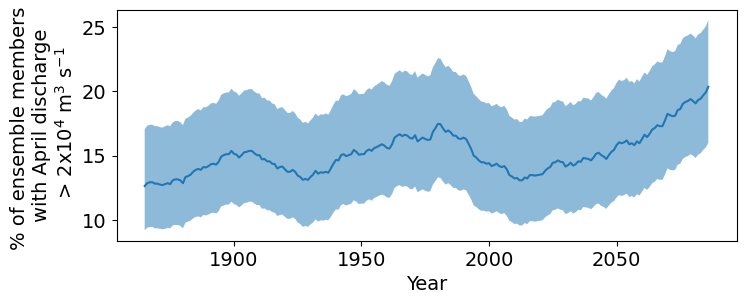

In [21]:
# Plot proportion of ensemble members with high April discharge (rolling mean applied)
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,1,figsize = (8,3))
ax.plot(df_ext30.index,df_ext30.ext)
ax.fill_between(df_ext30.index, df_ext30.cilow, df_ext30.cihigh,alpha = 0.5)
ax.set_ylabel('% of ensemble members \n with April discharge \n > 2x10$^4$ m$^3$ s$^{-1}$')
ax.set_xlabel('Year')
# ax.set_title('April')

# fig.tight_layout()
# fig.savefig('cesm_april_trend.pdf')